# Performance Metrics

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
pp = pd.read_csv("cte_lateral_pp.csv")
mpc = pd.read_csv("cte_lateral_mpc.csv")
ftg = pd.read_csv("lateral_ftg.csv")

In [10]:
pp.head(), mpc.head(), ftg.head()

(   elapsed time       cte  lat_accel
 0         0.292  0.143256   0.794881
 1         0.342  0.137129   1.535679
 2         0.774  0.132384   4.283851
 3         0.823  0.129129   7.790745
 4         0.875  0.127078   6.169248,
    elapsed time       cte  lat_accel
 0         2.730  0.129762        0.0
 1         2.730  0.129762        0.0
 2         2.730  0.129762        0.0
 3         2.730  0.129762        0.0
 4         2.782  0.129762        0.0,
    elapsed time  lat_accel
 0         0.292   0.285799
 1         0.357   1.770580
 2         0.416   1.243161
 3         0.482   3.867198
 4         0.537   3.378211)

In [19]:
def extract_time_window(df, t_start, duration=8.0):
    t_end = t_start + duration
    return df[(df["elapsed time"] >= t_start) & (df["elapsed time"] <= t_end)]

In [20]:
t_start = 20.0

In [21]:
pp_seg  = extract_time_window(pp, t_start)
mpc_seg = extract_time_window(mpc, t_start)
ftg_seg = extract_time_window(ftg, t_start)

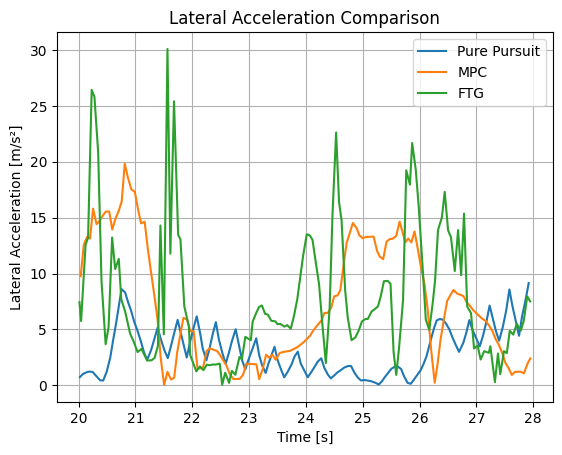

In [22]:
plt.figure()
plt.plot(pp_seg["elapsed time"], pp_seg["lat_accel"], label="Pure Pursuit")
plt.plot(mpc_seg["elapsed time"], mpc_seg["lat_accel"], label="MPC")
plt.plot(ftg_seg["elapsed time"], ftg_seg["lat_accel"], label="FTG")

plt.xlabel("Time [s]")
plt.ylabel("Lateral Acceleration [m/s²]")
plt.title("Lateral Acceleration Comparison")
plt.legend()
plt.grid(True)
plt.show()

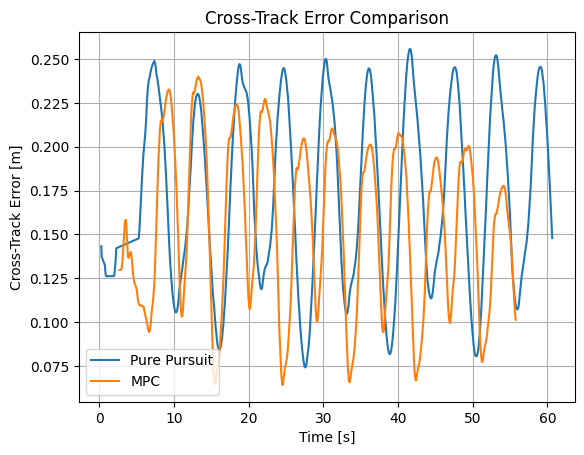

In [24]:
plt.figure()
plt.plot(pp["elapsed time"], pp["cte"], label="Pure Pursuit")
plt.plot(mpc["elapsed time"], mpc["cte"], label="MPC")

plt.xlabel("Time [s]")
plt.ylabel("Cross-Track Error [m]")
plt.title("Cross-Track Error Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
mean_cte_pp = pp["cte"].abs().mean()
mean_cte_mpc = mpc["cte"].abs().mean()

print(f"Mean CTE (Pure Pursuit): {mean_cte_pp:.3f} m")
print(f"Mean CTE (MPC): {mean_cte_mpc:.3f} m")

Mean CTE (Pure Pursuit): 0.174 m
Mean CTE (MPC): 0.152 m


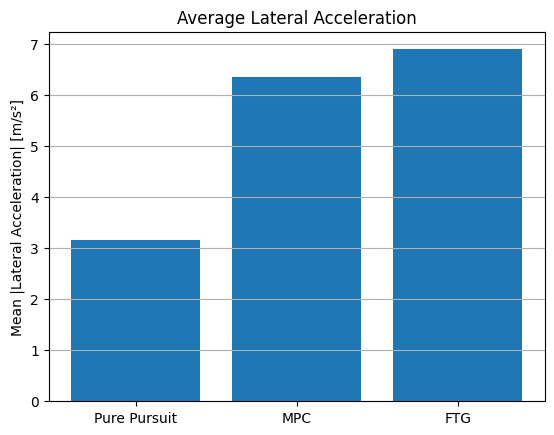

In [9]:
mean_lat = {
    "Pure Pursuit": pp["lat_accel"].abs().mean(),
    "MPC": mpc["lat_accel"].abs().mean(),
    "FTG": ftg["lat_accel"].abs().mean()
}

plt.figure()
plt.bar(mean_lat.keys(), mean_lat.values())
plt.ylabel("Mean |Lateral Acceleration| [m/s²]")
plt.title("Average Lateral Acceleration")
plt.grid(axis="y")
plt.show()

In [61]:
mean_lat.keys(), mean_lat.values()

(dict_keys(['Pure Pursuit', 'MPC', 'FTG']),
 dict_values([np.float64(3.169473253511862), np.float64(6.358342065036365), np.float64(6.900888974865692)]))

# States

In [25]:
pp_states = pd.read_csv("pp_states.csv")
mpc_states = pd.read_csv("mpc_states.csv")
ftg_states = pd.read_csv("ftg_states.csv")
pid_states = pd.read_csv("pid_states.csv")

In [26]:
pp_states.head()

,elapsed time,throttle,speed,steering,lap
0,1.895,1.0,0.0000,0.169366,10.0024
1,1.957,1.0,0.0000,0.169366,10.0784
2,2.014,1.0,0.0309,0.169382,10.1455
3,2.069,1.0,0.3180,0.169224,10.1995
4,2.123,1.0,0.5910,0.151291,10.2515


In [42]:
def extract_segment(df, t_start, duration=10.0):
    t_end = t_start + duration
    return df[(df["elapsed time"] >= t_start) & (df["elapsed time"] <= t_end)]

# Example: segment starting at 40s
t_start = 20.0
duration = 8.0
pp_seg  = extract_segment(pp_states, t_start,duration)
mpc_seg = extract_segment(mpc_states, t_start,duration)
ftg_seg = extract_segment(ftg_states, t_start,duration)
pid_seg = extract_segment(pid_states, t_start,duration)

# Normalize time to start at 0 for plotting
def normalize_time(df):
    df = df.copy()
    df["elapsed time"] = df["elapsed time"] - df["elapsed time"].iloc[0]
    return df

pp_seg  = normalize_time(pp_seg)
mpc_seg = normalize_time(mpc_seg)
ftg_seg = normalize_time(ftg_seg)
pid_seg = normalize_time(pid_seg)

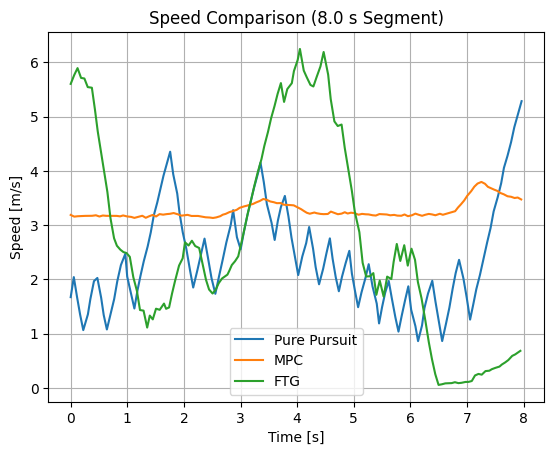

In [43]:
plt.figure()
plt.plot(pp_seg["elapsed time"], pp_seg["speed"], label="Pure Pursuit")
plt.plot(mpc_seg["elapsed time"], mpc_seg["speed"], label="MPC")
plt.plot(ftg_seg["elapsed time"], ftg_seg["speed"], label="FTG")

plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Speed Comparison ("+str(duration)+" s Segment)")
plt.legend()
plt.grid(True)
plt.show()

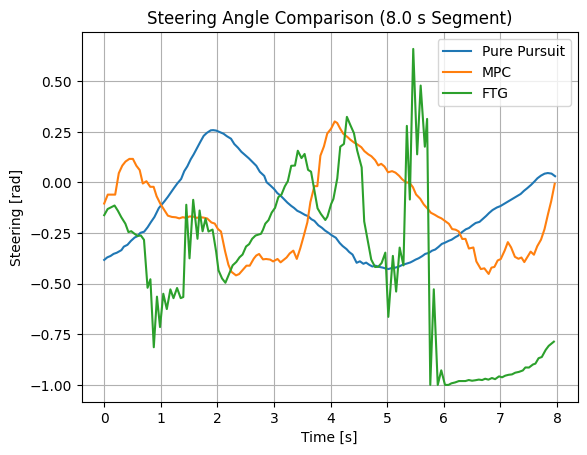

In [44]:
plt.figure()
plt.plot(pp_seg["elapsed time"], pp_seg["steering"], label="Pure Pursuit")
plt.plot(mpc_seg["elapsed time"], mpc_seg["steering"], label="MPC")
plt.plot(ftg_seg["elapsed time"], ftg_seg["steering"], label="FTG")

plt.xlabel("Time [s]")
plt.ylabel("Steering [rad]")
plt.title("Steering Angle Comparison ("+str(duration)+" s Segment)")
plt.legend()
plt.grid(True)
plt.show()

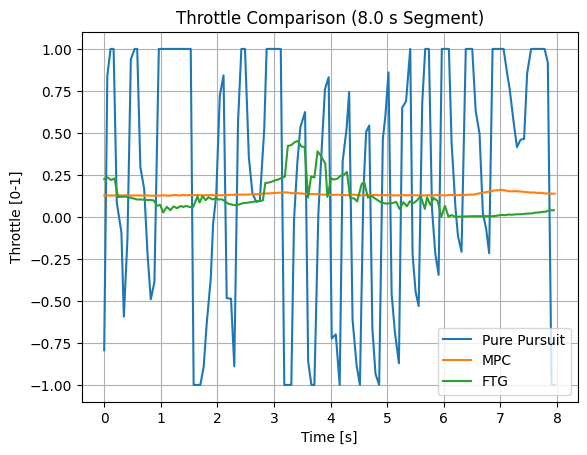

In [45]:
plt.figure()
plt.plot(pp_seg["elapsed time"], pp_seg["throttle"], label="Pure Pursuit")
plt.plot(mpc_seg["elapsed time"], mpc_seg["throttle"], label="MPC")
plt.plot(ftg_seg["elapsed time"], ftg_seg["throttle"], label="FTG")

plt.xlabel("Time [s]")
plt.ylabel("Throttle [0-1]")
plt.title("Throttle Comparison ("+str(duration)+" s Segment)")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
def extract_metrics(df):
    metrics = {}

    # Mean and std of speed
    metrics["mean_speed"] = df["speed"].mean()
    metrics["std_speed"] = df["speed"].std()

    # Max speed
    metrics["max_speed"] = df["speed"].max()

    # Steering RMS and rate
    metrics["steering_rms"] = np.sqrt((df["steering"]**2).mean())
    steering_rate = df["steering"].diff() / df["elapsed time"].diff()
    metrics["steering_rate_mean"] = steering_rate.abs().mean()

    # Throttle RMS
    metrics["throttle_rms"] = np.sqrt((df["throttle"]**2).mean())

    # Lap time metrics
    lap_groups = df.groupby(df["lap"].astype(int))
    lap_times = lap_groups["elapsed time"].max()
    metrics["lap_time_mean"] = lap_times.mean()
    metrics["lap_time_std"] = lap_times.std()

    return metrics

pp_metrics = extract_metrics(pp_seg)
mpc_metrics = extract_metrics(mpc_seg)
ftg_metrics = extract_metrics(ftg_seg)

In [53]:
import pprint
print("Pure Pursuit Metrics:")
pprint.pprint(pp_metrics)
print("\nMPC Metrics:")
pprint.pprint(mpc_metrics)
print("\nFTG Metrics:")
pprint.pprint(ftg_metrics)

Pure Pursuit Metrics:
{'lap_time_mean': np.float64(4.420500000000002),
 'lap_time_std': 2.72538618058677,
 'max_speed': 5.28319978713989,
 'mean_speed': np.float64(2.387659704507287),
 'std_speed': 0.9338636359546002,
 'steering_rate_mean': np.float64(0.23331319087760682),
 'steering_rms': np.float64(0.24945895487132053),
 'throttle_rms': np.float64(0.7645760303876333)}

MPC Metrics:
{'lap_time_mean': np.float64(4.634888888888887),
 'lap_time_std': 2.604012550106299,
 'max_speed': 3.79579997062683,
 'mean_speed': np.float64(3.2788215490487906),
 'std_speed': 0.1592363551339083,
 'steering_rate_mean': np.float64(0.4192691376246218),
 'steering_rms': np.float64(0.2559548686250592),
 'throttle_rms': np.float64(0.13469355488207352)}

FTG Metrics:
{'lap_time_mean': np.float64(3.7358999999999996),
 'lap_time_std': 2.842478708998734,
 'max_speed': 6.24510002136231,
 'mean_speed': np.float64(2.7128281604912545),
 'std_speed': 1.8824619246421583,
 'steering_rate_mean': np.float64(1.625730968288

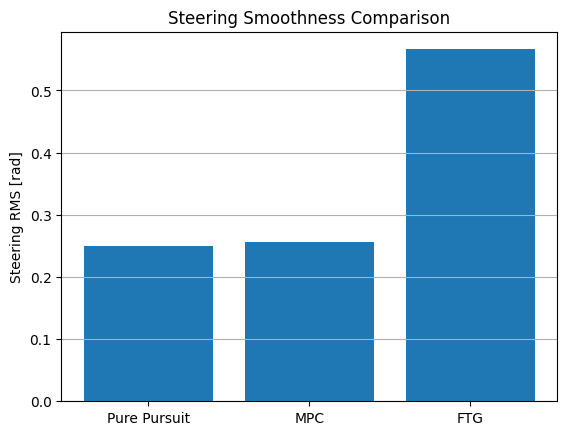

In [54]:
steering_rms = {
    "Pure Pursuit": pp_metrics["steering_rms"],
    "MPC": mpc_metrics["steering_rms"],
    "FTG": ftg_metrics["steering_rms"]
}

plt.figure()
plt.bar(steering_rms.keys(), steering_rms.values())
plt.ylabel("Steering RMS [rad]")
plt.title("Steering Smoothness Comparison")
plt.grid(axis="y")
plt.show()

In [58]:
pp_df = pd.read_csv("pp_states.csv")
mpc_df = pd.read_csv("mpc_states.csv")
ftg_df = pd.read_csv("ftg_states.csv")

def extract_metrics(df):
    metrics = {}

    # Speed
    metrics["max_speed"] = df["speed"].max()
    metrics["mean_speed"] = df["speed"].mean()
    metrics["std_speed"] = df["speed"].std()

    # Steering
    metrics["steering_rms"] = np.sqrt((df["steering"]**2).mean())
    steering_rate = df["steering"].diff() / df["elapsed time"].diff()
    metrics["steering_rate_mean"] = steering_rate.abs().mean()

    # Throttle
    metrics["throttle_rms"] = np.sqrt((df["throttle"]**2).mean())

    # Lap time
    lap_groups = df.groupby(df["lap"].astype(int))
    lap_times = lap_groups["elapsed time"].max()
    metrics["lap_time_mean"] = lap_times.mean()
    metrics["lap_time_std"] = lap_times.std()

    return metrics

pp_metrics = extract_metrics(pp_df)
mpc_metrics = extract_metrics(mpc_df)
ftg_metrics = extract_metrics(ftg_df)


In [59]:
metrics_df = pd.DataFrame({
    "Pure Pursuit": pp_metrics,
    "MPC": mpc_metrics,
    "FTG": ftg_metrics
}).T  # Transpose to have controllers as rows

# Round values for readability
metrics_df = metrics_df.round(3)

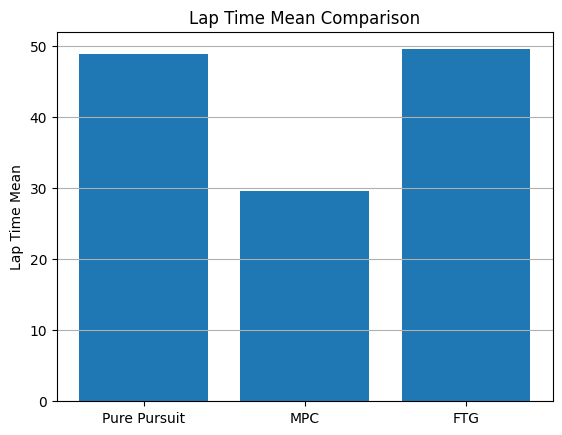

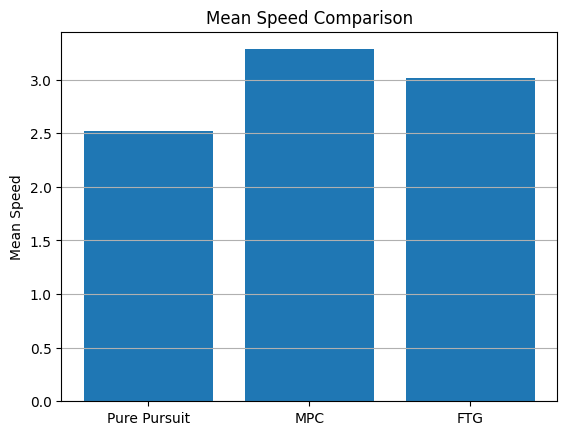

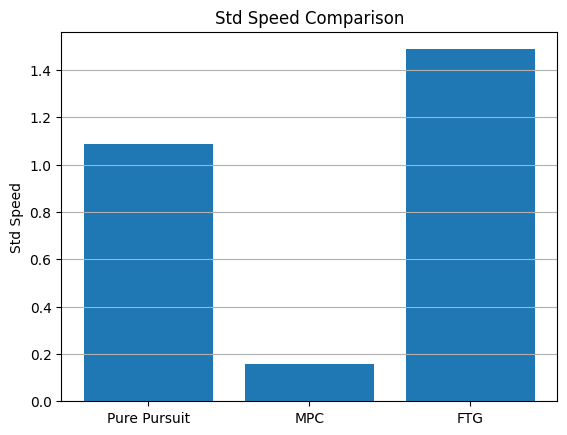

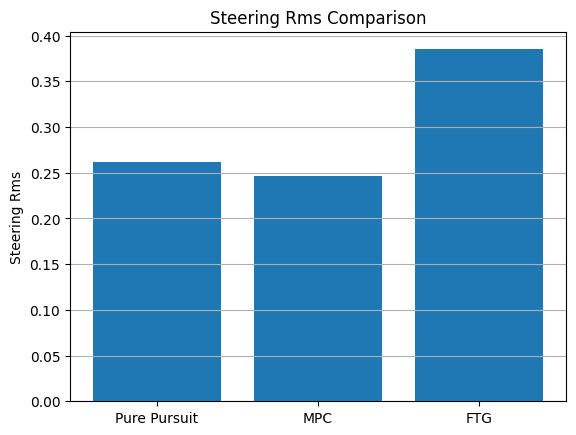

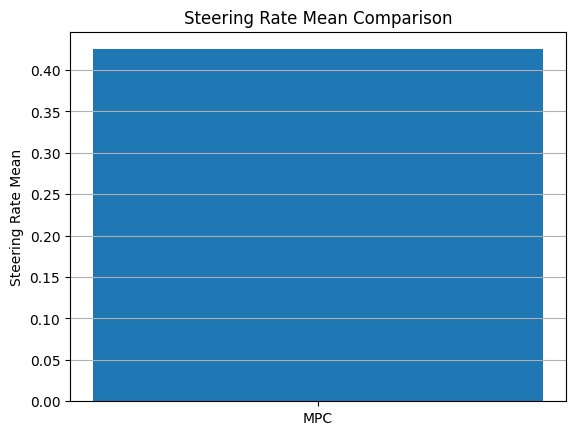

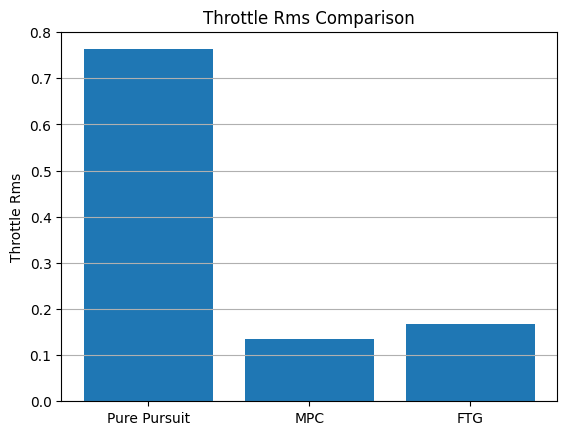

In [60]:
selected_metrics = ["lap_time_mean", "mean_speed", "std_speed", "steering_rms", "steering_rate_mean", "throttle_rms"]

for metric in selected_metrics:
    plt.figure()
    plt.bar(metrics_df.index, metrics_df[metric])
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} Comparison")
    plt.grid(axis="y")
    plt.show()